# Evaluation

This notebook contains the code used to perform the evaluation of the resulting tracking system. We compare, using a small set of test sequences, the performance of some different configurations.

In [5]:
import os
from typing import Any

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [1]:
import util
import visualize
import dataset
import detect
import tracker

In [ ]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(visualize)
importlib.reload(dataset)
importlib.reload(detect)
importlib.reload(tracker)

#### Running the System on the Test Sequences

First, we will run the system on all the test sequences. We will run it using the five available sizes of the YOLO model used by the system and using a different number of available camera views.

In [3]:
data = dataset.CmuPanopticDataset()

In [ ]:
physics = tracker.build_physics()
physics.to("cuda")

for model in ["yolo26n-pose", "yolo26s-pose", "yolo26m-pose", "yolo26l-pose"]:
    detector = detect.PoseDetector(model_name=model)
    detector.to("cuda")
    for scene in data.test_scenes:
        # We only use more than 4 cameras for the smallest model.
        for n_cams in [4, 8, 12, 16] if model == "yolo26n-pose" else [4]:
            print(
                f"running for {scene} with {n_cams} cameras using {model}...")
            # Only perform if we don't have the result yet, to enable resuming.
            if not os.path.exists(f"./stats/eval/{model}/{n_cams}/{scene}-times.json"):
                source = data.get_source(scene, num_vga_cams=n_cams)
                source.to("cuda")
                track = tracker.Tracker(detector, physics)
                cams, frames, fps = track.evaluate(source, progress=0)
                util.save_tracks(
                    f"./stats/eval/{model}/{n_cams}/{scene}.json", cams, frames, fps)
                util.save_json(
                    f"./stats/eval/{model}/{n_cams}/{scene}-times.json", track.timing_stats)

running for 171204_pose6 with 4 cameras using yolo26n-pose...
running for 171204_pose6 with 8 cameras using yolo26n-pose...
running for 171204_pose6 with 12 cameras using yolo26n-pose...
running for 171204_pose6 with 16 cameras using yolo26n-pose...
running for 161029_piano4 with 4 cameras using yolo26n-pose...
running for 161029_piano4 with 8 cameras using yolo26n-pose...
running for 161029_piano4 with 12 cameras using yolo26n-pose...
running for 161029_piano4 with 16 cameras using yolo26n-pose...
running for 170915_office1 with 4 cameras using yolo26n-pose...
running for 170915_office1 with 8 cameras using yolo26n-pose...
running for 170915_office1 with 12 cameras using yolo26n-pose...
running for 170915_office1 with 16 cameras using yolo26n-pose...
running for 161029_build1 with 4 cameras using yolo26n-pose...
running for 161029_build1 with 8 cameras using yolo26n-pose...
running for 161029_build1 with 12 cameras using yolo26n-pose...
running for 161029_build1 with 16 cameras using 

Next to actually do the evaluation we also need the ground truth tracks. I extract them here ones into the same format as the track predictions, and then we can load them again for computing evaluation metrics.

In [ ]:
for scene in data.test_scenes:
    cams_gt, frames_gt, fps_gt = data.load_ground_truth_vga(scene)
    util.save_tracks(f"./stats/gt/{scene}.json", cams_gt, frames_gt, fps_gt)

Perform performing visualizations of the results, we need to actually compute the metrics for each evaluation run.

In [ ]:
for model in ["yolo26n-pose", "yolo26s-pose", "yolo26m-pose", "yolo26l-pose"]:
    for scene in data.test_scenes:
        for n_cams in [4, 8, 12, 16] if model == "yolo26n-pose" else [4]:
            print(
                f"running for {scene} with {n_cams} cameras using {model}...")
            # Only perform if we don't have the result yet, to enable resuming.
            if not os.path.exists(f"./stats/eval/{model}/{n_cams}/{scene}-metrics.json"):
                metrics = util.evaluate_from_files(
                    f"./stats/gt/{scene}.json", f"./stats/eval/{model}/{n_cams}/{scene}.json")
                util.save_json(
                    f"./stats/eval/{model}/{n_cams}/{scene}-metrics.json", metrics)

running for 171204_pose6 with 4 cameras using yolo26n-pose...
running for 171204_pose6 with 8 cameras using yolo26n-pose...
running for 171204_pose6 with 12 cameras using yolo26n-pose...
running for 171204_pose6 with 16 cameras using yolo26n-pose...
running for 161029_piano4 with 4 cameras using yolo26n-pose...
running for 161029_piano4 with 8 cameras using yolo26n-pose...
running for 161029_piano4 with 12 cameras using yolo26n-pose...
running for 161029_piano4 with 16 cameras using yolo26n-pose...
running for 170915_office1 with 4 cameras using yolo26n-pose...
running for 170915_office1 with 8 cameras using yolo26n-pose...
running for 170915_office1 with 12 cameras using yolo26n-pose...
running for 170915_office1 with 16 cameras using yolo26n-pose...
running for 161029_build1 with 4 cameras using yolo26n-pose...
running for 161029_build1 with 8 cameras using yolo26n-pose...
running for 161029_build1 with 12 cameras using yolo26n-pose...
running for 161029_build1 with 16 cameras using 

Now that we have the evaluation results for all sequences, we merge them into a large dataset for further processing.

In [6]:
df = []
for model in ["yolo26n-pose", "yolo26s-pose", "yolo26m-pose", "yolo26l-pose"]:
    for scene in data.test_scenes:
        for n_cams in [4, 8, 12, 16] if model == "yolo26n-pose" else [4]:
            metrics = util.load_json(
                f"./stats/eval/{model}/{n_cams}/{scene}-metrics.json")
            times = util.load_json(
                f"./stats/eval/{model}/{n_cams}/{scene}-times.json")
            df.append({
                "model": model, "scene": scene, "n_cams": n_cams,
                "MPJPE": metrics["MPJPE"], "MOTA": metrics["MOTA"],
                "MOTP": metrics["MOTP (Avg Miss Distance)"],
                "Precision": metrics["Precision"], "Recall": metrics["Recall"],
                "t_detection": times["detection"][0] / times["detection"][1],
                "t_matching_old": times["matching_old"][0] / times["matching_old"][1],
                "t_matching_new": times["matching_new"][0] / times["matching_new"][1],
                "t_update": times["update"][0] / times["update"][1],
                "t_create_new": times["create_new"][0] / times["create_new"][1],
                "t_prediction": times["prediction"][0] / times["prediction"][1],
            })
df: Any = pd.DataFrame(df)
df.to_csv("stats/results.csv", index=False)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   model           35 non-null     str    
 1   scene           35 non-null     str    
 2   n_cams          35 non-null     int64  
 3   MPJPE           35 non-null     float64
 4   MOTA            35 non-null     float64
 5   MOTP            35 non-null     float64
 6   Precision       35 non-null     float64
 7   Recall          35 non-null     float64
 8   t_detection     35 non-null     float64
 9   t_matching_old  35 non-null     float64
 10  t_matching_new  35 non-null     float64
 11  t_update        35 non-null     float64
 12  t_create_new    35 non-null     float64
 13  t_prediction    35 non-null     float64
dtypes: float64(11), int64(1), str(2)
memory usage: 4.0 KB


In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {"font.size": 11, "axes.labelsize": 12, "axes.titlesize": 14})

#### Performance on Test Set

Next we will examine the performance of different configurations of the tracking system on the held-out test sequences. We evaluate using both pose estimation and object tracking related metrics.

In [8]:
df_4cams = df[df["n_cams"] == 4].copy()
# Note that there is once scene that is corrupted for >= 12 cameras. We remove
# it here from the calculations to retain valid results.
df_yolo_scaling = df[(df["model"] == "yolo26n-pose") &
                     (df["scene"] != "171204_pose6")].copy()

First, let's look at the performance difference when using different model capacities.

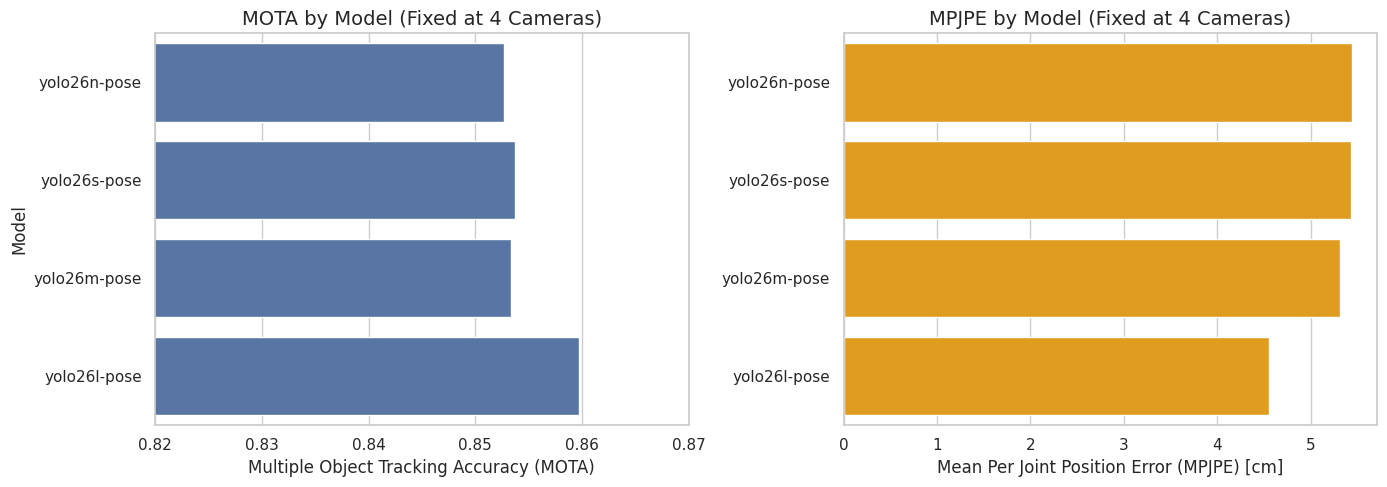

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MOTA comparison (higher is better)
ax = sns.barplot(
    data=df_4cams, x="MOTA", y="model", ax=axes[0], errorbar=None,
    order=["yolo26n-pose", "yolo26s-pose", "yolo26m-pose", "yolo26l-pose"]
)
axes[0].set_title("MOTA by Model (Fixed at 4 Cameras)")
axes[0].set_xlabel("Multiple Object Tracking Accuracy (MOTA)")
axes[0].set_ylabel("Model")
axes[0].set_xlim(0.82, 0.87)

# MPJPE comparison (lower is better)
sns.barplot(
    data=df_4cams, x="MPJPE", y="model", ax=axes[1], color="orange", errorbar=None,
    order=["yolo26n-pose", "yolo26s-pose", "yolo26m-pose", "yolo26l-pose"]
)
axes[1].set_title("MPJPE by Model (Fixed at 4 Cameras)")
axes[1].set_xlabel("Mean Per Joint Position Error (MPJPE) [cm]")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../report/figures/model_comparison_4_cams.pdf")
plt.show()

Next let us analyze the efficacy of scaling up the number of used cameras.

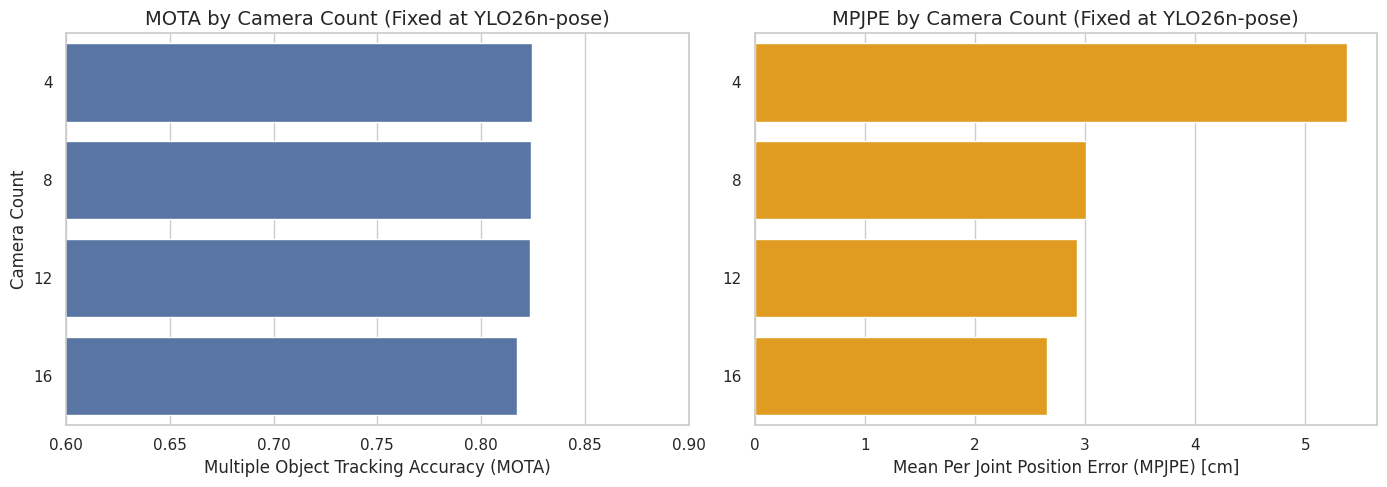

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MOTA comparison (higher is better)
ax = sns.barplot(
    data=df_yolo_scaling, x="MOTA", y="n_cams", ax=axes[0],
    errorbar=None, order=[4, 8, 12, 16], orient="h"
)
axes[0].set_title("MOTA by Camera Count (Fixed at YLO26n-pose)")
axes[0].set_xlabel("Multiple Object Tracking Accuracy (MOTA)")
axes[0].set_ylabel("Camera Count")
axes[0].set_xlim(0.60, 0.90)

# MPJPE comparison (lower is better)
sns.barplot(
    data=df_yolo_scaling, x="MPJPE", y="n_cams", ax=axes[1], color="orange",
    errorbar=None, order=[4, 8, 12, 16], orient="h"
)
axes[1].set_title("MPJPE by Camera Count (Fixed at YLO26n-pose)")
axes[1].set_xlabel("Mean Per Joint Position Error (MPJPE) [cm]")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../report/figures/camera_count_comparison.pdf")
plt.show()

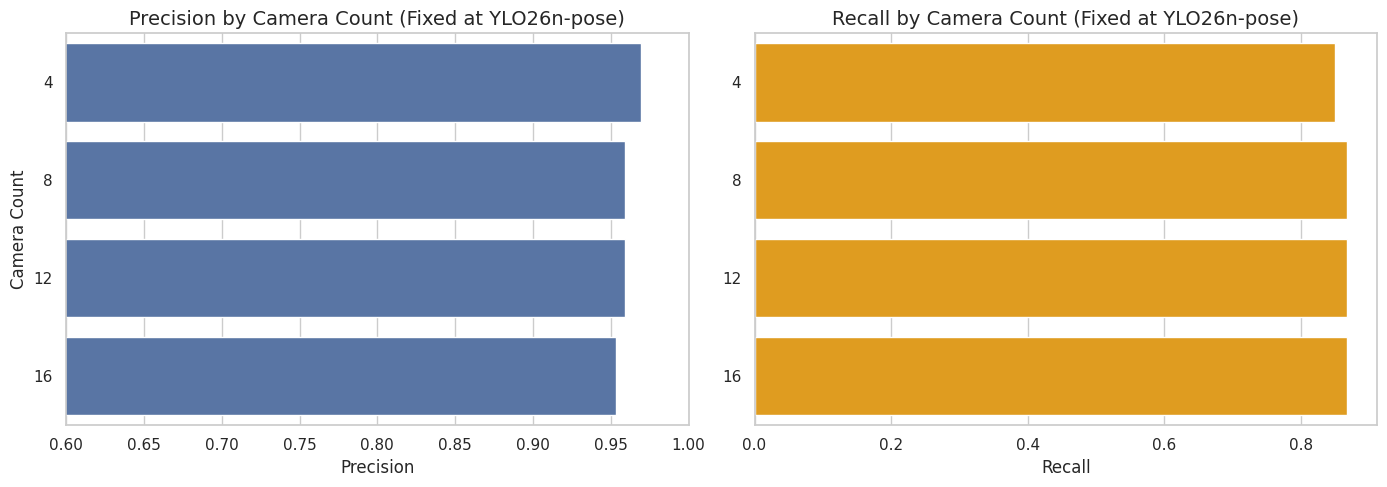

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision comparison (higher is better)
ax = sns.barplot(
    data=df_yolo_scaling, x="Precision", y="n_cams", ax=axes[0],
    errorbar=None, order=[4, 8, 12, 16], orient="h"
)
axes[0].set_title("Precision by Camera Count (Fixed at YLO26n-pose)")
axes[0].set_xlabel("Precision")
axes[0].set_ylabel("Camera Count")
axes[0].set_xlim(0.85, 1.00)

# Recall comparison (higher is better)
sns.barplot(
    data=df_yolo_scaling, x="Recall", y="n_cams", ax=axes[1], color="orange",
    errorbar=None, order=[4, 8, 12, 16], orient="h"
)
axes[1].set_title("Recall by Camera Count (Fixed at YLO26n-pose)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("")
axes[0].set_xlim(0.60, 1.00)

plt.tight_layout()
plt.savefig("../report/figures/camera_count_comparison_precision.pdf")
plt.show()

Now let us look also at the runtime breakdown.

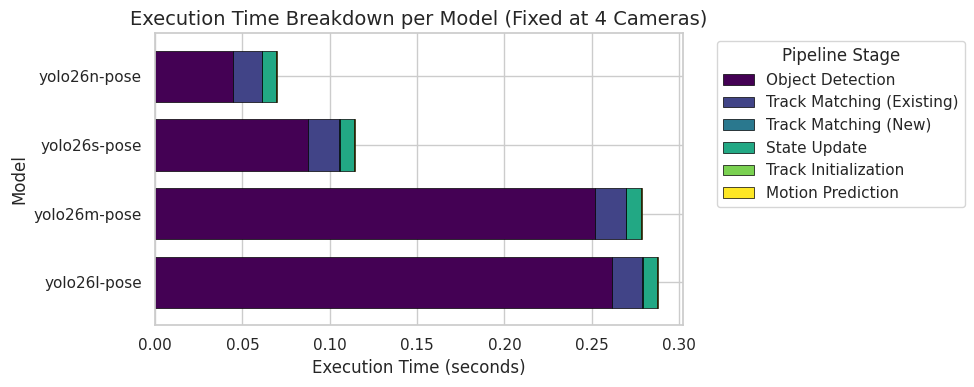

In [ ]:
# Breaks down execution times across models under identical environment conditions.
time_cols = [
    "t_detection", "t_matching_old", "t_matching_new", "t_update", "t_create_new", "t_prediction"
]
stage_rename_map = {
    "t_detection": "Object Detection",
    "t_matching_old": "Track Matching (Existing)",
    "t_matching_new": "Track Matching (New)",
    "t_update": "State Update",
    "t_create_new": "Track Initialization",
    "t_prediction": "Motion Prediction"
}

df_time_sorted = df_4cams.groupby("model")[time_cols].mean()\
    .sort_values(by="t_detection", ascending=False)

ax = df_time_sorted[time_cols].plot(
    kind="barh", stacked=True, figsize=(10, 4),
    colormap="viridis", edgecolor="black", linewidth=0.5,
    width=0.75
)
handles, labels = ax.get_legend_handles_labels()

new_labels = [stage_rename_map.get(label, label) for label in labels]
plt.title("Execution Time Breakdown per Model (Fixed at 4 Cameras)")
plt.xlabel("Execution Time (seconds)")
plt.ylabel("Model")
plt.legend(handles, new_labels, title="Pipeline Stage",
           bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../report/figures/execution_time_breakdown_4_cams.pdf")
plt.show()

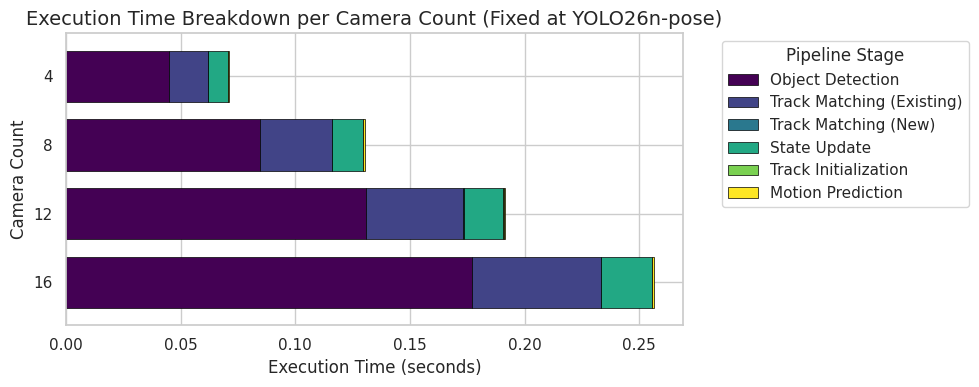

In [71]:
# Breaks down execution times across models under identical environment conditions.
time_cols = [
    "t_detection", "t_matching_old", "t_matching_new", "t_update", "t_create_new", "t_prediction"
]
stage_rename_map = {
    "t_detection": "Object Detection",
    "t_matching_old": "Track Matching (Existing)",
    "t_matching_new": "Track Matching (New)",
    "t_update": "State Update",
    "t_create_new": "Track Initialization",
    "t_prediction": "Motion Prediction"
}

df_time_sorted = df_yolo_scaling.groupby("n_cams")[time_cols].mean()\
    .sort_values(by="t_detection", ascending=False)

ax = df_time_sorted[time_cols].plot(
    kind="barh", stacked=True, figsize=(10, 4),
    colormap="viridis", edgecolor="black", linewidth=0.5,
    width=0.75
)
handles, labels = ax.get_legend_handles_labels()

new_labels = [stage_rename_map.get(label, label) for label in labels]
plt.title("Execution Time Breakdown per Camera Count (Fixed at YOLO26n-pose)")
plt.xlabel("Execution Time (seconds)")
plt.ylabel("Camera Count")
plt.legend(handles, new_labels, title="Pipeline Stage",
           bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../report/figures/execution_time_breakdown_cams.pdf")
plt.show()

Now we generate some tables for use in the report.

In [13]:
runtime_cols = [
    't_detection', 't_matching_old', 't_matching_new', 
    't_update', 't_create_new', 't_prediction'
]
performance_cols = [
    'MOTA', 'MOTP', 'MPJPE', 'Precision', 'Recall'
]
df_performance = df.groupby(['model', 'n_cams'])[performance_cols].mean()

df_runtimes = df.groupby(['model', 'n_cams'])[runtime_cols].mean()
df_runtimes['t_total'] = df_runtimes.sum(axis=1)

df_scene_performance = df_4cams.groupby(['scene'])[performance_cols].mean()

print("=== PERFORMANCE METRICS TABLE ===")
print(df_performance.round(3).to_markdown())

print("\n=== RUNTIMES TABLE (seconds) ===")
print(df_runtimes.round(4).to_markdown())

print("\n=== SCENE DIFFICULTY ANALYSIS TABLE ===")
print(df_scene_performance.round(3).to_markdown())

=== PERFORMANCE METRICS TABLE ===
|                      |   MOTA |   MOTP |   MPJPE |   Precision |   Recall |
|:---------------------|-------:|-------:|--------:|------------:|---------:|
| ('yolo26l-pose', 4)  |  0.86  |  4.252 |   4.554 |       0.974 |    0.883 |
| ('yolo26m-pose', 4)  |  0.853 |  4.745 |   5.318 |       0.972 |    0.88  |
| ('yolo26n-pose', 4)  |  0.853 |  5.004 |   5.439 |       0.972 |    0.877 |
| ('yolo26n-pose', 8)  |  0.854 |  2.912 |   2.967 |       0.963 |    0.894 |
| ('yolo26n-pose', 12) |  0.691 |  2.795 |   2.845 |       0.961 |    0.728 |
| ('yolo26n-pose', 16) |  0.686 |  2.515 |   2.576 |       0.953 |    0.728 |
| ('yolo26s-pose', 4)  |  0.854 |  4.957 |   5.427 |       0.972 |    0.879 |

=== RUNTIMES TABLE (seconds) ===
|                      |   t_detection |   t_matching_old |   t_matching_new |   t_update |   t_create_new |   t_prediction |   t_total |
|:---------------------|--------------:|-----------------:|-----------------:|-----------:|-

#### Qualitative Results

In this section we just look at some example sequence to compare how the differently configured tracking systems perform.

In [79]:
visualize.load_from_files(
    "stats/eval/yolo26l-pose/4/160224_haggling1.json",
    "stats/gt/160224_haggling1.json",
).show()

Widget(value='<iframe src="http://localhost:35075/index.html?ui=P_0x7f09d27c9a90_0&reconnect=auto" class="pyvi…

In [2]:
visualize.load_from_files(
    "stats/eval/yolo26l-pose/4/161029_build1.json",
    "stats/gt/161029_build1.json",
).show()

Widget(value='<iframe src="http://localhost:41831/index.html?ui=P_0x7fc50bd9ea50_0&reconnect=auto" class="pyvi…

In [2]:
visualize.load_from_files(
    "stats/eval/yolo26n-pose/4/160224_haggling1.json",
    "stats/gt/160224_haggling1.json",
).show()

Widget(value='<iframe src="http://localhost:32795/index.html?ui=P_0x7f9186f5ea50_0&reconnect=auto" class="pyvi…

In [14]:
visualize.load_from_files(
    "stats/eval/yolo26n-pose/4/161029_piano4.json",
    "stats/gt/161029_piano4.json",
).show()

Widget(value='<iframe src="http://localhost:44409/index.html?ui=P_0x7f7ee8821160_0&reconnect=auto" class="pyvi…